In [16]:
import json

# Open the JSON file and load its content
with open('checkpoints/rmd17_aspirin/experiment_results.json', 'r') as file:
    data = json.load(file)

# Now 'data' is a Python dictionary or list
print(data[0].keys())

dict_keys(['run_name', 'run_uuid', 'best_loss', 'run_ckpt_dir', 'metadata_dir', 'teacher', 'student', 'distillation_metrics', 'n_test', 'split_id', 'splits_dir', 'checkpoint_run', 'energy', 'forces'])


In [17]:
print(data[0]["student"].keys())

dict_keys(['run_name', 'best_loss', 'run_ckpt_dir', 'test_metrics', 'test_target_source', 'auc_excess_valid_loss'])


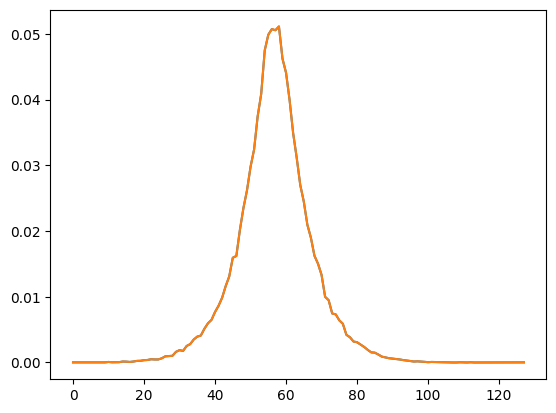

In [9]:
import matplotlib.pyplot as plt
plt.plot(data[0]["distillation_metrics"]["teacher_hist"])
plt.plot(data[0]["distillation_metrics"]["student_hist"])

In [11]:
data[0]["distillation_metrics"].keys()

dict_keys(['kl_teacher_to_student_test_force_hist', 'kl_student_to_teacher_test_force_hist', 'force_hist_bins', 'force_hist_range', 'teacher_hist_sum', 'student_hist_sum', 'teacher_hist', 'student_hist', 'hist_bin_edges'])

In [1]:
import numpy as np
import pandas as pd
import ase
from tqdm import tqdm

from mmml.interfaces.chemcoordInterface.interface import patch_chemcoord_for_pandas3
patch_chemcoord_for_pandas3()

from mmml.generate.sample.compare_ensemble_entropy import (
    process_ensemble_frames,
    _make_soap,
    ase_to_chemcoord,
    construction_table_from_zmat,
)


def scan_information_content(
    pool,
    window_size=10,
    stride=10,
    stop=None,
    soap_species=("C", "H", "O"),
    soap_nmax=10,
    soap_lmax=10,
    soap_rcut=3.0,
    soap_sigma=0.5,
):
    R = get_pool_array(pool, "R")
    Z = get_pool_array(pool, "Z")
    E = get_pool_array(pool, "E").reshape(len(R), -1)
    F = get_pool_array(pool, "F")

    n_frames = len(R)
    stop = n_frames if stop is None else min(stop, n_frames)

    z0 = Z[0] if Z.ndim == 2 else Z
    ref_atoms = ase.Atoms(numbers=z0, positions=R[0])

    cc_atoms = ase_to_chemcoord(ref_atoms)
    ref_zmat = cc_atoms.get_zmat()
    c_table = construction_table_from_zmat(ref_zmat)

    soap_engine = _make_soap(
        list(soap_species),
        soap_rcut,
        soap_nmax,
        soap_lmax,
        soap_sigma,
    )

    rows = []

    for start in tqdm(range(0, stop - window_size + 1, stride)):
        end = start + window_size
        idx = np.arange(start, end)

        frames = [
            ase.Atoms(numbers=Z[i] if Z.ndim == 2 else Z, positions=R[i])
            for i in idx
        ]

        info = process_ensemble_frames(
            frames,
            label=f"window_{start}_{end}",
            soap_engine=soap_engine,
            c_table=c_table,
        )

        Ei = E[idx]
        Fi = F[idx]

        rows.append({
            "start": start,
            "end": end,
            "indices": idx,
            "E_min": float(Ei.min()),
            "E_max": float(Ei.max()),
            "E_mean": float(Ei.mean()),
            "F_min": float(Fi.min()),
            "F_max": float(Fi.max()),
            "F_abs_mean": float(np.abs(Fi).mean()),
            **info,
        })

    return pd.DataFrame(rows)

    
def get_pool_array(pool, key):
    # dict / npz-like
    if hasattr(pool, "keys"):
        if key in pool.keys():
            return np.asarray(pool[key])
        if key.lower() in pool.keys():
            return np.asarray(pool[key.lower()])
        if key.upper() in pool.keys():
            return np.asarray(pool[key.upper()])

    # attribute-style object
    if hasattr(pool, key):
        return np.asarray(getattr(pool, key))
    if hasattr(pool, key.lower()):
        return np.asarray(getattr(pool, key.lower()))
    if hasattr(pool, key.upper()):
        return np.asarray(getattr(pool, key.upper()))

    raise KeyError(f"Could not find {key} in pool")

def make_info_split(
    info_df,
    metric="gzip_bytes_zmat",
    train_fraction=0.8,
):
    """
    Select highest-information windows for training.

    The top `train_fraction` windows by `metric` go to training.
    The remaining lower-information windows go to validation.
    """
    if metric not in info_df.columns:
        raise ValueError(f"Metric {metric!r} not found in info_df")

    ranked = info_df.sort_values(metric, ascending=False).reset_index(drop=True)

    n_train = max(1, round(train_fraction * len(ranked)))

    train_windows = ranked.iloc[:n_train]
    valid_windows = ranked.iloc[n_train:]

    train_idx = np.unique(np.concatenate(train_windows["indices"].to_numpy()))
    valid_idx = np.unique(np.concatenate(valid_windows["indices"].to_numpy()))

    # Avoid overlap if stride < window_size.
    valid_idx = np.setdiff1d(valid_idx, train_idx)

    return train_idx, valid_idx, train_windows, valid_windows

# PhysNet training on MD17 / rMD17 data

Train PhysNetJax on a **bring-your-own** MD17 or revised MD17 (rMD17) NPZ file.

**Input keys (rMD17):** `nuclear_charges`, `coords`, `energies`, `forces`  
**Units:** Å, kcal/mol, kcal/mol/Å

**Splits:** official test indices are held out first (`rmd17/splits/index_test_*.csv`); train/valid are sampled only from `index_train_*.csv` (≤ 1000 structures recommended).

## 1. Configuration

In [2]:
import os
from pathlib import Path

# --- point this at your NPZ file ---
DATA_PATH = Path("/scicore/home/meuwly/boitti0000/data/rmd17/npz_data/rmd17_aspirin.npz")

# Official rMD17 splits (Materials Cloud: rmd17/splits/index_{train,test}_0X.csv)
# None = auto-detect as <rmd17>/splits next to npz_data/
RMD17_SPLITS_DIR = None
SPLIT_ID = 1  # fold 01 .. 05

# Train/valid drawn only from official train pool (after test is held out)
N_TRAIN = 950
N_VALID = 50
SEED = 42

NUM_EPOCHS = 1000
BATCH_SIZE = 50
LEARNING_RATE = 1e-3

MAX_STRUCTURES = None  # set e.g. 200 for a quick smoke test
CONVERT_TO_EV = True   # kcal/mol -> eV (matches PhysNetJax defaults)

CKPT_DIR = Path("checkpoints/rmd17_aspirin")
RUN_NAME = f"rmd17_aspirin_split{SPLIT_ID:02d}"
SAVE_EVERY_EPOCH = True





## 2. Load rMD17 data

In [28]:
import numpy as np
import jax

from mmml.data.rmd17 import load_rmd17_npz
from mmml.data.loaders import get_data_statistics

raw = np.load(DATA_PATH, allow_pickle=True)
print("NPZ keys:", list(raw.keys()))
for k in raw.keys():
    v = raw[k]
    print(f"  {k:20s} shape={getattr(v, 'shape', '?')}")

data = load_rmd17_npz(
    DATA_PATH,
    convert_to_ev=CONVERT_TO_EV,
    max_structures=MAX_STRUCTURES,
)

num_atoms = int(data["N"].max())
print(f"\nMolecule size: {num_atoms} atoms")
print(f"Loaded {len(data['E'])} structures")
print(get_data_statistics(data))

NPZ keys: ['nuclear_charges', 'coords', 'energies', 'forces', 'old_indices', 'old_energies', 'old_forces']
  nuclear_charges      shape=(21,)
  coords               shape=(100000, 21, 3)
  energies             shape=(100000,)
  forces               shape=(100000, 21, 3)
  old_indices          shape=(100000,)
  old_energies         shape=(100000,)
  old_forces           shape=(100000, 21, 3)

Molecule size: 21 atoms
Loaded 100000 structures
{'n_structures': 100000, 'keys': ['R', 'Z', 'E', 'F', 'N'], 'coordinates': {'shape': (100000, 21, 3), 'min': -4.65956281, 'max': 4.29439374, 'mean': 0.030610013074822223, 'std': 1.7225924286359109}, 'energy': {'min': -17618.571922085277, 'max': -17616.07628949394, 'mean': -17617.72544280078, 'std': 0.2674003397699598}, 'forces': {'shape': (100000, 21, 3), 'min': -9.055684974031637, 'max': 9.644050745369093, 'mean': 9.753868807100689e-12, 'std': 1.273361205776416}, 'elements': {'unique': [1, 6, 8], 'counts': {1: 800000, 6: 900000, 8: 400000}}}


In [29]:
def subset_arrays(d, idx):
    out = {}
    for key, value in d.items():
        if isinstance(value, np.ndarray) and value.shape[0] == n_total:
            out[key] = value[idx]
        else:
            out[key] = value
    return out


from mmml.data.rmd17 import load_rmd17_official_splits, resolve_rmd17_splits_dir

splits_dir = resolve_rmd17_splits_dir(DATA_PATH, RMD17_SPLITS_DIR)
official_train_pool, test_idx = load_rmd17_official_splits(splits_dir, SPLIT_ID)

n_total = len(data["E"])
assert official_train_pool.max() < n_total and test_idx.max() < n_total, (
    "Split indices out of range for loaded NPZ"
)
assert N_TRAIN + N_VALID <= len(official_train_pool), (
    f"Need {N_TRAIN + N_VALID} train-pool samples, "
    f"official fold has {len(official_train_pool)}"
)

# 1) Hold out official test set first
test_data = subset_arrays(data, test_idx)

In [30]:
len(official_train_pool)

1000

In [31]:
official_train_pool_data = subset_arrays(data, official_train_pool)

In [32]:
len(official_train_pool_data["E"])

1000

In [33]:
info_df

,start,end,indices,E_min,E_max,E_mean,F_min,F_max,F_abs_mean,path,...,gzip_bytes_zmat,gzip_bytes_soap,bits_per_frame_cart,bits_per_frame_zmat,bits_per_frame_soap,shannon_pca2d_soap,ipr_pca2d_soap,shannon_cc_dist_1d,soap_dim,soap_array
0,0,10,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",-17618.363711,-17617.361792,-17617.816422,-6.333196,4.910512,0.904861,window_0_10,...,4886,397828,3946.4,3908.8,318262.4,3.321928,10.0,3.321928,5115,"[[0.009725276608382037, 0.01623601699430135, 0..."
1,10,20,"[10, 11, 12, 13, 14, 15, 16, 17, 18, 19]",-17617.991865,-17617.257774,-17617.669953,-4.623229,4.766601,1.007583,window_10_20,...,4890,397700,3947.2,3912.0,318160.0,3.321928,10.0,3.321928,5115,"[[0.009688556731339813, 0.016167539685504013, ..."
2,20,30,"[20, 21, 22, 23, 24, 25, 26, 27, 28, 29]",-17618.051083,-17617.405613,-17617.660422,-4.783824,3.958311,0.980895,window_20_30,...,4880,397755,3940.8,3904.0,318204.0,3.321928,10.0,3.121928,5115,"[[0.009749695309325089, 0.016287653234888556, ..."
3,30,40,"[30, 31, 32, 33, 34, 35, 36, 37, 38, 39]",-17617.903414,-17617.107042,-17617.554774,-5.910314,4.389807,0.953638,window_30_40,...,4882,397729,3930.4,3905.6,318183.2,3.321928,10.0,2.921928,5115,"[[0.00976431672088498, 0.016300555668742896, 0..."
4,40,50,"[40, 41, 42, 43, 44, 45, 46, 47, 48, 49]",-17617.962370,-17616.973980,-17617.665841,-4.710325,4.595749,0.984772,window_40_50,...,4885,397709,3937.6,3908.0,318167.2,3.321928,10.0,3.321928,5115,"[[0.009715080067082398, 0.016213793983544708, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,950,960,"[950, 951, 952, 953, 954, 955, 956, 957, 958, ...",-17617.888693,-17617.492658,-17617.720441,-5.556711,4.663957,0.903318,window_950_960,...,4884,397657,3941.6,3907.2,318125.6,3.321928,10.0,3.121928,5115,"[[0.009727062477343191, 0.016221946361754214, ..."
96,960,970,"[960, 961, 962, 963, 964, 965, 966, 967, 968, ...",-17617.929916,-17617.110706,-17617.595216,-6.196670,5.307986,1.042556,window_960_970,...,4880,397693,3938.4,3904.0,318154.4,3.321928,10.0,3.321928,5115,"[[0.009666370098541953, 0.016129510490495314, ..."
97,970,980,"[970, 971, 972, 973, 974, 975, 976, 977, 978, ...",-17617.934471,-17617.411298,-17617.633510,-6.578280,4.881750,0.986796,window_970_980,...,4882,397726,3939.2,3905.6,318180.8,3.321928,10.0,2.521928,5115,"[[0.009738564636513663, 0.016239610134926544, ..."
98,980,990,"[980, 981, 982, 983, 984, 985, 986, 987, 988, ...",-17618.219963,-17616.984223,-17617.740060,-4.911333,5.221927,0.969469,window_980_990,...,4880,397697,3948.0,3904.0,318157.6,3.321928,10.0,3.321928,5115,"[[0.009718688394672836, 0.01621643917467341, 0..."


In [34]:
N_ws = 2


info_df = scan_information_content(
    official_train_pool_data,
    window_size=N_ws,
    stride=N_ws,
)

100%|██████████| 500/500 [00:21<00:00, 23.77it/s]


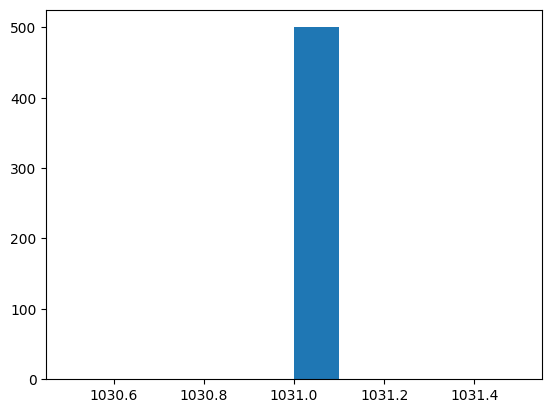

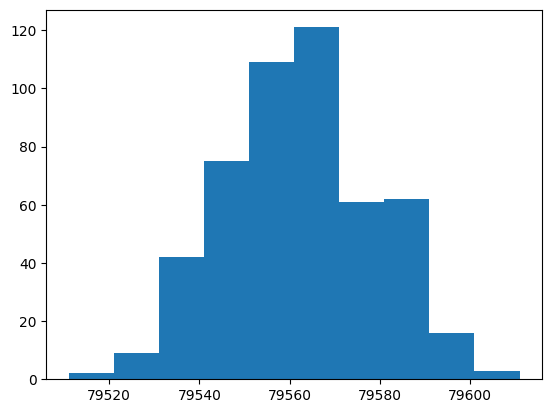

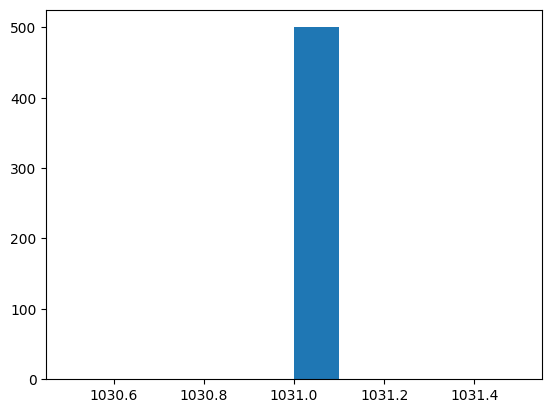

In [35]:
import matplotlib.pyplot as plt
plt.hist(info_df["gzip_bytes_zmat"])
plt.show()
plt.hist(info_df["gzip_bytes_soap"])
plt.show()
plt.hist(info_df["gzip_bytes_cart"])
plt.show()


In [36]:
train_idx, valid_idx, train_windows, valid_windows = make_info_split(
    info_df,
    metric="gzip_bytes_cart",
    train_fraction=0.95,
)

In [37]:
train_pool = {
    k: np.asarray(v)[train_idx]
    for k, v in official_train_pool_data.items()
}

valid_pool = {
    k: np.asarray(v)[valid_idx]
    for k, v in official_train_pool_data.items()
}

In [38]:
train_pool["E"].shape, valid_pool["E"].shape

((950, 1), (50, 1))

## 3. Official test holdout, then train / validation

1. **Test** — indices from `index_test_{SPLIT_ID:02d}.csv` (never used for training).
2. **Train / valid** — random subset of `index_train_{SPLIT_ID:02d}.csv` only.

In [39]:
RANDOM = False
if RANDOM:
    # 2) Train / valid from official train pool only
    rng = np.random.RandomState(SEED)
    perm = rng.permutation(len(official_train_pool))
    train_idx = official_train_pool[perm[:N_TRAIN]]
    valid_idx = official_train_pool[perm[N_TRAIN : N_TRAIN + N_VALID]]
    
    train_data = subset_arrays(data, train_idx)
    valid_data = subset_arrays(data, valid_idx)
    
    assert not (set(train_idx) & set(test_idx))
    assert not (set(valid_idx) & set(test_idx))
    
    print(f"Splits dir: {splits_dir}")
    print(f"Official fold {SPLIT_ID:02d}: train pool={len(official_train_pool)}, test={len(test_idx)}")
    print(f"Train: {len(train_data['E'])}  Valid: {len(valid_data['E'])}  Test: {len(test_data['E'])}")
else:
    train_data = train_pool.copy()
    valid_data = valid_pool.copy()

train_data_E_mean = train_data["E"].mean()
train_data["E"] = train_data["E"] - train_data_E_mean
valid_data["E"] = valid_data["E"] - train_data_E_mean
test_data["E"] = test_data["E"] - train_data_E_mean



## 4. Model & training

In [57]:
from mmml.physnetjax.physnetjax.models.model import EF
from mmml.physnetjax.physnetjax.training.training import train_model

print("JAX devices:", jax.devices())

key = jax.random.PRNGKey(SEED)

model = EF(
    features=32,
    max_degree=0,
    num_iterations=2,
    num_basis_functions=32,
    cutoff=10.0,
    natoms=num_atoms,
    max_atomic_number=int(data["Z"].max()),
    charges=False,
    zbl=False,
)

ema_params, best_loss = train_model(
    key=key,
    model=model,
    train_data=train_data,
    valid_data=valid_data,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    num_atoms=num_atoms,
    energy_weight=1.0,
    forces_weight=52.91,
    data_keys=("R", "Z", "F", "E", "N"),
    name=RUN_NAME,
    ckpt_dir=CKPT_DIR,
    best=True,
    save_every_epoch=SAVE_EVERY_EPOCH,
    batch_method="default",
    log_tb=False,
    print_freq=1,
)

run_dirs = sorted(CKPT_DIR.glob(f"{RUN_NAME}-*"))
RUN_CKPT_DIR = run_dirs[-1] if run_dirs else None

print(f"\nDone. Best validation objective: {best_loss:.6f}")
print(f"Checkpoints ({NUM_EPOCHS} epochs): {RUN_CKPT_DIR}")

JAX devices: [CudaDevice(id=0)]


                            Train Data                            
┏━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Key ┃ Shape + Stats                                            ┃
┡━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ R   │ shape=(950, 21, 3) x∈[-4.586, 4.24] μ=0.02968 σ=1.721    │
│ Z   │ shape=(950, 21) x∈[1, 8]                                 │
│ E   │ shape=(950, 1) x∈[-0.6396, 0.8573] μ=2.566e-13 σ=0.2596  │
│ F   │ shape=(950, 21, 3) x∈[-6.789, 7.11] μ=-2.234e-11 σ=1.259 │
│ N   │ shape=(950, 1) x∈[21, 21]                                │
└─────┴──────────────────────────────────────────────────────────┘

                         Validation Data                          
┏━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Key ┃ Shape + Stats                                            ┃
┡━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ R   │ shape=(50, 21, 3) x∈[-4.274, 4.212] μ=0.03451 σ=1.721    │
│ Z   │ shape=(50, 21) x∈[1, 8]                                  │
│ E   │ shape=(50, 1) x∈[-0.5375, 0.7541] μ=0.03446 σ=0.2618     │
│ F   │ shape=(50, 21, 3) x∈[-6.578, 5.308] μ=-2.122e-10 σ=1.294 │
│ N   │ shape=(50, 1) x∈[21, 21]                                 │
└─────┴──────────────────────────────────────────────────────────┘

Using default (fat) batching method


Training Routine

...

                                   Training Style                                   
┏━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ restart ┃ best ┃ save_every_epoch ┃ data_keys                 ┃ objective        ┃
┡━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ False   │ True │ True             │ ('R', 'Z', 'F', 'E', 'N') │ valid_forces_mae │
└─────────┴──────┴──────────────────┴───────────────────────────┴──────────────────┘

                            Validation Batch[0]                            
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Key            ┃ Shape + Stats                                          ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ R              │ shape=(1050, 3) x∈[-4.274, 4.212] μ=0.03451 σ=1.721    │
│ Z              │ shape=(1050,) x∈[1, 8]                                 │
│ F              │ shape=(1050, 3) x∈[-6.578, 5.308] μ=-2.122e-10 σ=1.294 │
│ E              │ shape=(50, 1) x∈[-0.5375, 0.7541] μ=0.03446 σ=0.2618   │
│ N              │ shape=(50,) x∈[21, 21]                                 │
│ dst_idx        │ shape=(21000,) x∈[0, 1049]                             │
│ src_idx        │ shape=(21000,) x∈[0, 1049]                             │
│ batch_mask     │ shape=(21000,) x∈[1, 1]                                │
│ batch_segments │ shape=(1050,) x∈[0, 49]                                │
│ atom_mask      │ shape=(1050,) x∈[1, 1]                                 │
└────────────────┴────────────────────────────────────────────────────────┘

                                                                                                  Model Attributes                                                                                                  
┏━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ features ┃ max_degree ┃ num_iterations ┃ num_basis_functions ┃ cutoff ┃ max_atomic_number ┃ charges ┃ natoms ┃ total_charge ┃ n_res ┃ zbl   ┃ debug ┃ efa   ┃ use_energy_bias ┃ use_pbc ┃ include_electrostatics ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 32       │ 0          │ 2              │ 32                  │ 10.0   │ 8                 │ False   │ 21     │ 0            │ 3     │ False │ False │ False │ False           │ False   │ True                   │
└──────────┴────────────┴────────────────┴─────────────────────┴────────┴───────────────────┴─────────┴────────┴──────────────┴───────┴───────┴───────┴───────┴─────────────────┴─────────┴────────────────────────┘

Output()


Done. Best validation objective: Array gpu:0 2.070
Checkpoints (1000 epochs): checkpoints/rmd17_aspirin/rmd17_aspirin_split01-d9008da1-b411-4e63-bbe7-f0ae22539999


In [59]:
CKPT_DIR
RUN_CKPT_DIR

Path('checkpoints/rmd17_aspirin/rmd17_aspirin_split01-d9008da1-b411-4e63-bbe7-f0ae22539999')

In [60]:
EVAL_DIR = RUN_CKPT_DIR / f"test_eval_split{SPLIT_ID:02d}"

## 5. Official test-set evaluation

Evaluate on the held-out **official** test indices (`index_test_{SPLIT_ID:02d}.csv`). Metrics are in kcal/mol (same convention as `mmml physnet-evaluate`).

Test batches: 20 × batch_size=50


20it [00:11,  1.75it/s]


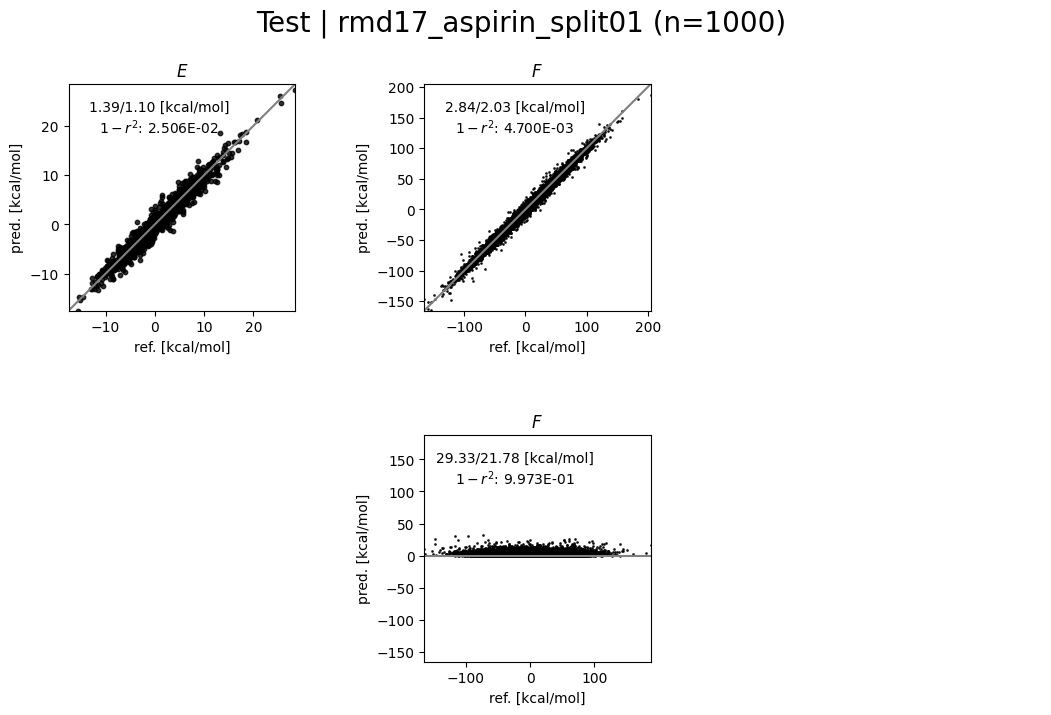

Energy  MAE=1.0986 kcal/mol  (0.0476 eV)
Forces  MAE=2.0272 kcal/mol/Å  (0.0879 eV/Å)
Wrote checkpoints/rmd17_aspirin/rmd17_aspirin_split01-d9008da1-b411-4e63-bbe7-f0ae22539999/test_eval_split01/test_metrics.json
Wrote checkpoints/rmd17_aspirin/rmd17_aspirin_split01-d9008da1-b411-4e63-bbe7-f0ae22539999/test_eval_split01/parity_test.png


In [61]:
import json
import matplotlib.pyplot as plt

from mmml.physnetjax.physnetjax.data.batches import prepare_batches_jit
from mmml.physnetjax.physnetjax.analysis.analysis import plot_stats

key_eval, _ = jax.random.split(jax.random.PRNGKey(SEED + 1))
test_batches = prepare_batches_jit(
    key_eval,
    test_data,
    BATCH_SIZE,
    data_keys=("R", "Z", "F", "E", "N"),
    num_atoms=num_atoms,
)

print(f"Test batches: {len(test_batches)} × batch_size={BATCH_SIZE}")

stats = plot_stats(
    test_batches,
    model,
    ema_params,
    _set=f"Test | {RUN_NAME}",
    do_kde=False,
    batch_size=BATCH_SIZE,
    do_plot=True,
)

EV_PER_KCAL = 0.043364106370
metrics = {
    "n_test": int(len(test_data["E"])),
    "split_id": SPLIT_ID,
    "splits_dir": str(splits_dir),
    "checkpoint_run": str(RUN_CKPT_DIR) if RUN_CKPT_DIR else None,
    "energy": {
        "mae_kcal_mol": float(stats["E_mae"]),
        "rmse_kcal_mol": float(stats["E_rmse"]),
        "mae_ev": float(stats["E_mae"]) * EV_PER_KCAL,
        "rmse_ev": float(stats["E_rmse"]) * EV_PER_KCAL,
    },
    "forces": {
        "mae_kcal_mol": float(stats["F_mae"]),
        "rmse_kcal_mol": float(stats["F_rmse"]),
        "mae_ev": float(stats["F_mae"]) * EV_PER_KCAL,
        "rmse_ev": float(stats["F_rmse"]) * EV_PER_KCAL,
    },
}

EVAL_DIR.mkdir(parents=True, exist_ok=True)
with open(EVAL_DIR / "test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

fig_path = EVAL_DIR / "parity_test.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print(
    f"Energy  MAE={metrics['energy']['mae_kcal_mol']:.4f} kcal/mol  "
    f"({metrics['energy']['mae_ev']:.4f} eV)"
)
print(
    f"Forces  MAE={metrics['forces']['mae_kcal_mol']:.4f} kcal/mol/Å  "
    f"({metrics['forces']['mae_ev']:.4f} eV/Å)"
)
print(f"Wrote {EVAL_DIR / 'test_metrics.json'}")
print(f"Wrote {fig_path}")

## 6. (Optional) Save converted MMML NPZ

In [79]:
SAVE_CONVERTED = False

if SAVE_CONVERTED:
    out_dir = Path("rmd17_converted")
    out_dir.mkdir(exist_ok=True)
    np.savez(out_dir / "train.npz", **train_data)
    np.savez(out_dir / "valid.npz", **valid_data)
    np.savez(out_dir / "test.npz", **test_data)
    print("Saved:", out_dir / "train.npz", out_dir / "valid.npz", out_dir / "test.npz")

In [80]:

#/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin

# rmd17_aspirin_split01-c2cedc1e-493e-49b0-bc87-42545de422b8

In [81]:
#rmd17_aspirin_split01-86778d97-f308-47c8-a448-1e285fd43946

In [45]:
ckpts = list(Path("/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-86778d97-f308-47c8-a448-1e285fd43946").glob("*"))
ckpts = list(Path("/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-c2cedc1e-493e-49b0-bc87-42545de422b8").glob("*"))
ckpts = list(Path("/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-c1c5bcd3-f1fa-4186-b834-afa7176a99f7").glob("*"))
ckpts = list(Path("/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-488b442b-7db5-473f-8399-66fc94117761").glob("*"))


ckpts = list(Path("/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-33b3ba55-0bbc-4beb-9c7a-35ede13ce6ff").glob("*"))
ckpts = list(Path("/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-7d84d7f9-9603-44ec-abfd-c6ad4b469a83").glob("*"))


In [46]:
ckpts


[Path('/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-7d84d7f9-9603-44ec-abfd-c6ad4b469a83/epoch-640'),
 Path('/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-7d84d7f9-9603-44ec-abfd-c6ad4b469a83/epoch-112'),
 Path('/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-7d84d7f9-9603-44ec-abfd-c6ad4b469a83/epoch-343'),
 Path('/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-7d84d7f9-9603-44ec-abfd-c6ad4b469a83/epoch-945'),
 Path('/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-7d84d7f9-9603-44ec-abfd-c6ad4b469a83/epoch-948'),
 Path('/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-7d84d7f9-9603-44ec-abfd-c6ad4b469a83/epoch-958'),
 Path('/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-7d84d7f9-9603-

In [47]:
ckpts.sort(key=lambda x: int(str(x).split("/")[-1].split("-")[-1]))
ckpts

[Path('/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-7d84d7f9-9603-44ec-abfd-c6ad4b469a83/epoch-1'),
 Path('/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-7d84d7f9-9603-44ec-abfd-c6ad4b469a83/epoch-2'),
 Path('/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-7d84d7f9-9603-44ec-abfd-c6ad4b469a83/epoch-3'),
 Path('/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-7d84d7f9-9603-44ec-abfd-c6ad4b469a83/epoch-4'),
 Path('/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-7d84d7f9-9603-44ec-abfd-c6ad4b469a83/epoch-5'),
 Path('/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-7d84d7f9-9603-44ec-abfd-c6ad4b469a83/epoch-6'),
 Path('/scicore/home/meuwly/boitti0000/epiplexity/checkpoints/rmd17_aspirin/rmd17_aspirin_split01-7d84d7f9-9603-44ec-abfd-c6

In [48]:
import orbax.checkpoint

all_objectives = []
for _ in ckpts[::10]:
    restored = orbax.checkpoint.PyTreeCheckpointer().restore(_)
    ema_params = restored["ema_params"]
    epoch = restored["epoch"]
    best_loss = restored["best_loss"]
    objectives = restored["objectives"]  # MAE etc. for that epoch
    all_objectives.append(objectives)

/scicore/home/meuwly/boitti0000/mmml/.venv/lib/python3.13/site-packages/orbax/checkpoint/_src/serialization/jax_array_handlers.py:718: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


In [54]:
objectives

# restored

{'batch_size': 50,
 'charges_w': 14.39,
 'dipole_w': 27.21,
 'energy_w': 1.0,
 'forces_w': 52.91,
 'lr': Array gpu:0 0.001,
 'train_dipole_mae': Array gpu:0 0.,
 'train_energy_mae': Array gpu:0 3.513,
 'train_forces_mae': Array gpu:0 2.812,
 'train_loss': Array gpu:0 2.137,
 'valid_dipole_mae': Array gpu:0 0.,
 'valid_energy_mae': Array gpu:0 1.585,
 'valid_forces_mae': Array gpu:0 3.046,
 'valid_loss': Array gpu:0 2.822}

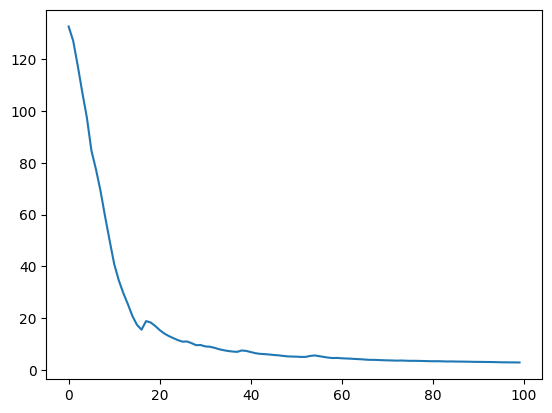

In [50]:
valid_losses = [_["valid_loss"] for _ in all_objectives]

plt.plot(valid_losses)

In [51]:
valid_losses_5 = valid_losses.copy()

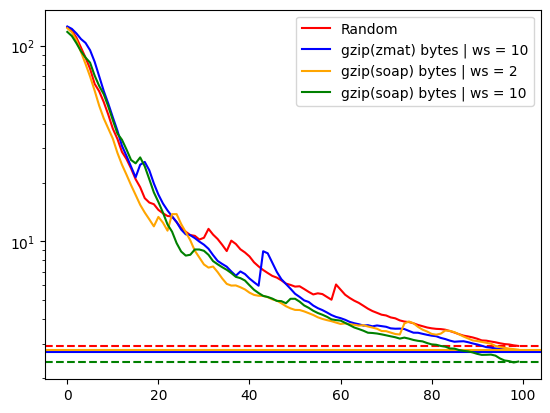

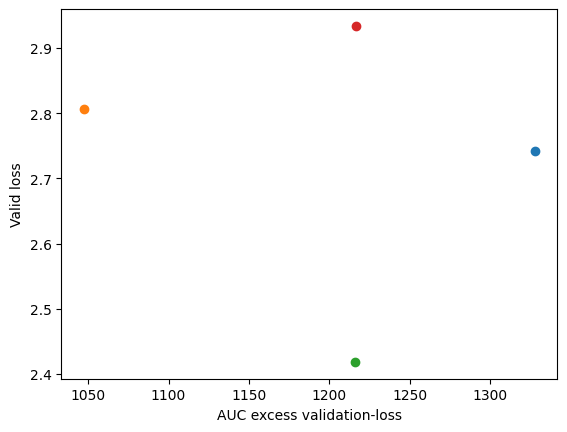

In [155]:
plt.plot(valid_losses_2, color="r", label="Random")
plt.axhline(valid_losses_2[-1], color="r", linestyle="--")

plt.plot(valid_losses_1, color="b", label="gzip(zmat) bytes | ws = 10")
plt.axhline(valid_losses_1[-1], color="b", linestyle="-")

plt.plot(valid_losses_3, color="orange", label="gzip(soap) bytes | ws = 2")
plt.axhline(valid_losses_3[-1], color="orange", linestyle="-")


plt.plot(valid_losses_4, color="g", label="gzip(soap) bytes | ws = 10")
plt.axhline(valid_losses_4[-1], color="g", linestyle="--")

plt.legend()
plt.yscale("log")
plt.show()
n_train = 100
for val_loss in [valid_losses_1,  valid_losses_3, valid_losses_4, valid_losses_2]:
    val_loss = np.asarray(val_loss, dtype=float)

    baseline = np.mean(val_loss[-2:])
    excess = np.maximum(val_loss - baseline, 0.0)
    # print(excess)
    epiplexity_proxy = np.trapezoid(excess)
    # print(baseline, epiplexity_proxy)
    plt.scatter(epiplexity_proxy, baseline)


plt.xlabel("AUC excess validation-loss")
plt.ylabel("Valid loss")
plt.show()

2.7417795658111572 1327.6784316301346
2.806652784347534 1047.3398076295853
2.418645739555359 1215.7873680591583
2.9337984323501587 1216.3343655467033


Text(0, 0.5, 'Valid loss')

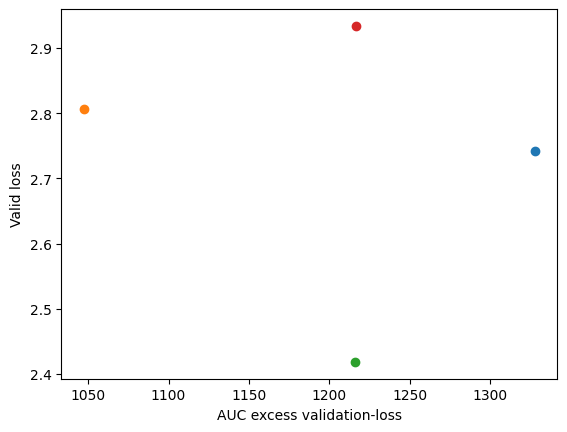

In [133]:
valid_losses_1 = np.array(valid_losses_1)
np.sum(valid_losses_1[valid_losses_1 > valid_losses_1[-1]]), valid_losses_1[-1]

(np.float32(1660.5748), np.float32(2.7307365))

In [134]:
valid_losses_2 = np.array(valid_losses_2)
np.sum(valid_losses_2[valid_losses_2 > valid_losses_2[-1]]),  valid_losses_2[-1]

(np.float32(1567.5364), np.float32(2.9238644))

In [136]:
valid_losses_3 = np.array(valid_losses_3)
np.sum(valid_losses_3[valid_losses_3 > valid_losses_3[-1]]), valid_losses_3[-1]

(np.float32(1385.4124), np.float32(2.7977223))

In [137]:
valid_losses_4 = np.array(valid_losses_4)
np.sum(valid_losses_4[valid_losses_4 > valid_losses_4[-1]]), valid_losses_4[-1]

(np.float32(1510.5497), np.float32(2.431395))

In [52]:
valid_losses_5 = np.array(valid_losses_5)
np.sum(valid_losses_5[valid_losses_5 > valid_losses_5[-1]]), valid_losses_5[-1]

(np.float32(1598.9), np.float32(2.822014))